In [1]:
import os
import json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from rapidfuzz import fuzz, process
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import SparsePCA
from sklearn.model_selection import train_test_split

### Load Data

In [38]:
main_directory = os.getenv("POND_PATH")
data_directory = os.getenv("POND_DATA_PATH")
text_directory = os.getenv("POND_TEXT_PATH")

In [3]:
# Directory
with open(os.path.join(main_directory, "directory.json"), "r") as f:
    paper_info = json.load(f)
registered_titles = [entry['title'] for entry in paper_info.values()]
registered_titles.sort()
registered_titles = registered_titles[:10]

# Original dataset
pond_data = pd.read_csv(os.path.join(data_directory, "pond_data.csv"), encoding_errors='ignore')
pond_data = pond_data.loc[pond_data.title.isin(registered_titles)]
pond_df = pond_data.loc[:,['author', 'title', 'pondname', 'location', 'author_term',
            'max_depth_m', 'mean_surfacearea_m2', 'macrophytes_percentcover', 'ph', 'tn_ugpl', 'tp_ugpl', 'chla_ugpl']]
pond_df.columns = ['author', 'title', 'name', 'location', 'ecosystem',
            'max_depth', 'surface_area', 'vegetation_cover', 'ph', 'tn', 'tp', 'chla']

# Split the dataframe's rows so that each measurement is in its own row
pond_df = pond_df.melt(id_vars=['author', 'title', 'name', 'location', 'ecosystem'], 
                       value_vars=['max_depth', 'surface_area', 'vegetation_cover', 'ph', 'tn', 'tp', 'chla'],
                       var_name='measurement', value_name='value')
pond_df = pond_df.dropna(subset=['value'])
pond_df = pond_df.reset_index(drop=True)
n_entries = pond_df.shape[0]

In [4]:
def process(
    result_df,
    conversion_table
):
    result_df = result_df.copy()

    # Drop rows without any measurements
    result_df = result_df.dropna(subset=['value'])
    result_df = result_df.reset_index(drop=True)

    # Convert units
    for row_idx, row in result_df.iterrows():
        measurement_type = row['measurement']
        val = row['value']
        unit = row['units']
        if conversion_table.get(measurement_type) is not None:
            if conversion_table[measurement_type].get(unit) is not None:
                conversion_factor = conversion_table[measurement_type][unit]
                result_df.at[row_idx, 'value'] = val * conversion_factor
            else:
                result_df.at[row_idx, 'value'] = np.nan # Units not recognized

    result_df = result_df.dropna(subset=['value'])
    result_df = result_df.reset_index(drop=True)

    # Drop all unit columns
    result_df = result_df.drop(columns=["units"])

    # Drop exact duplicates
    result_df = result_df.drop_duplicates()

    # Reset index
    result_df = result_df.reset_index(drop=True)

    return result_df


conversion_table = {
    'depth': {"cm": 0.01, "feet": 0.3048, "km": 1000, "m": 1},
    'surface_area': {"km^2": 1e6, "ha": 1e4, "mi^2": 2.59e6, "m^2": 1},
    'vegetation_cover': {"percent": 0.01, "fraction": 1},
    'tn': {"mg/L": 1000, "µg/L": 1, "μmol/L": 14.01, "ppm": 1000, "ppb": 1},
    'tp': {"mg/L": 1000, "µg/L": 1, "μmol/L": 30.97, "ppm": 1000, "ppb": 1},
    'chl': {"mg/L": 1000, "µg/L": 1}
}

In [5]:
ignore_measurements = ['latitude', 'longitude'] # Ignoring these for now because they are not in the original dataset

result_df = pd.read_csv('../data/pond_results_10_papers_better_ocr.csv')
result_df = result_df.loc[~result_df.measurement.isin(ignore_measurements)]
result_df['value'] = result_df['value'].str.replace(',', '')  # Remove commas from numbers
result_df['value'] = pd.to_numeric(result_df['value'], errors='coerce')
result_df = process(result_df, conversion_table)
result_df.sort_values(by=["title"], inplace=True)
result_df = result_df.reset_index(drop=True)

result_df_validated = pd.read_csv('../data/pond_results4_validated.csv')
result_df_validated = result_df_validated.loc[~result_df_validated.measurement.isin(ignore_measurements)]
result_df_validated['value'] = result_df_validated['value'].str.replace(',', '')  # Remove commas from numbers
result_df_validated['value'] = pd.to_numeric(result_df_validated['value'], errors='coerce')
result_df_validated = process(result_df_validated, conversion_table)

In [11]:
pond_df.loc[pond_df.title == registered_titles[7], :].sort_values(by='measurement')

,author,title,name,location,ecosystem,measurement,value
154,hsu,biodiversity of constructed wetlands for waste...,dn5,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,chla,149.9
142,hsu,biodiversity of constructed wetlands for waste...,hs2-1,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,chla,30.8
143,hsu,biodiversity of constructed wetlands for waste...,hs2-2,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,chla,26.3
144,hsu,biodiversity of constructed wetlands for waste...,hs2-3,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,chla,28.0
145,hsu,biodiversity of constructed wetlands for waste...,hs2-4,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,chla,46.0
...,...,...,...,...,...,...,...
67,hsu,biodiversity of constructed wetlands for waste...,hs2-2,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,vegetation_cover,65.0
66,hsu,biodiversity of constructed wetlands for waste...,hs2-1,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,vegetation_cover,20.0
78,hsu,biodiversity of constructed wetlands for waste...,dn5,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,vegetation_cover,20.0
71,hsu,biodiversity of constructed wetlands for waste...,dn1,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,vegetation_cover,5.0


In [32]:
result_df.loc[result_df.title == registered_titles[7], :].iloc[:, :12].sort_values(by='measurement')

,title,author,year,date,context,ecosystem,location,chunk_id,name,paper_id,measurement,value
138,biodiversity of constructed wetlands for waste...,hsu,2011,NaN,Our study showed that fish biodiversity was lo...,lake,Denmark,68,Danish lakes,7,surface_area,10000.000
133,biodiversity of constructed wetlands for waste...,hsu,2011,NaN,Our study showed that fish biodiversity was lo...,pond,Denmark,68,Danish ponds,7,surface_area,10000.000
132,biodiversity of constructed wetlands for waste...,hsu,2011,September 2006,<table>\n <tr>\n <th>Constructed wetland</...,wetland,NaN,20,Hsin-Hai II (HS2),7,surface_area,47000.000
131,biodiversity of constructed wetlands for waste...,hsu,2011,NaN,Areas of treatment cells varied within and bet...,pond,NaN,34,DN3-B,7,surface_area,2600.000
130,biodiversity of constructed wetlands for waste...,hsu,2011,1997,Changes in macrophyte composition and cover ar...,wetland,NaN,74,hemi-marshes,7,surface_area,500000.000
129,biodiversity of constructed wetlands for waste...,hsu,2011,NaN,A CCA was further used to examine relationship...,wetland,NaN,47,wetland,7,surface_area,100000.000
128,biodiversity of constructed wetlands for waste...,hsu,2011,November 2006,<table>\n <tr>\n <th>Constructed wetland</...,wetland,NaN,20,Daniaopi (DN),7,surface_area,130000.000
127,biodiversity of constructed wetlands for waste...,hsu,2011,NaN,Our study showed that fish biodiversity was lo...,wetland,NaN,68,constructed wetlands,7,surface_area,20000.000
126,biodiversity of constructed wetlands for waste...,hsu,2011,NaN,Areas of treatment cells varied within and bet...,pond,NaN,34,DN3-D,7,surface_area,2600.000
121,biodiversity of constructed wetlands for waste...,hsu,2011,NaN,Results from stepwise multiple regressions sho...,wetland,NaN,45,wetland,7,surface_area,7000000.000


In [37]:
print(result_df.loc[result_df.title == registered_titles[7], :].iloc[:, :11].sort_values(by='measurement').iloc[-1,:].context)

<table>
  <tr>
    <th rowspan="2">Aquatic macrophytes</th>
    <th colspan="5">HS2</th>
    <th colspan="7">DN</th>
  </tr>
  <tr>
    <th>HS2-1<sup>a</sup></th>
    <th>HS2-2</th>
    <th>HS2-3</th>
    <th>HS2-4</th>
    <th>HS2-5</th>
    <th>DN1</th>
    <th>DN2</th>
    <th>DN3-A</th>
    <th>DN3-B</th>
    <th>DN3-C</th>
    <th>DN3-D</th>
    <th>DN4</th>
    <th>DN5</th>
  </tr>
  <tr>
    <td><i>Brachiaria mutica</i></td>
    <td>7.5</td>
    <td>2.6</td>
    <td>1.8</td>
    <td>3.3</td>
    <td>4.3</td>
    <td>1.4</td>
    <td></td>
    <td></td>
    <td></td>
    <td></td>
    <td></td>
    <td></td>
    <td></td>
    <td></td>
  </tr>
  <tr>
    <td><i>Colocasia esculenta</i></td>
    <td>1.1</td>
    <td></td>
    <td></td>
    <td></td>
    <td></td>
    <td>1.5</td>
    <td></td>
    <td></td>
    <td></td>
    <td></td>
    <td></td>
    <td></td>
    <td></td>
    <td></td>
  </tr>
  <tr>
    <td><i>Cyperus imbricatus subsp. imbricatus</i></td>
    <td></td>
    <td

In [34]:
result_df.loc[result_df.title == registered_titles[7], :].iloc[:, :11]

,title,author,year,date,context,ecosystem,location,chunk_id,name,paper_id,measurement
112,biodiversity of constructed wetlands for waste...,hsu,2011,NaN,Constructed wetlands are often built for waste...,wetland,subtropical Taiwan,6,Daniaopi Constructed Wetlands,7,tn
113,biodiversity of constructed wetlands for waste...,hsu,2011,NaN,"the ecological ponds, and showed an increasing...",wetland,NaN,38,constructed wetlands,7,tp
114,biodiversity of constructed wetlands for waste...,hsu,2011,NaN,<table>\n <tr>\n <th>Parameter</th>\n <...,wetland,NaN,37,Hsin-Hai II constructed wetland,7,tp
115,biodiversity of constructed wetlands for waste...,hsu,2011,NaN,<table>\n <tr>\n <th>Parameter</th>\n <...,wetland,NaN,37,Daniaopi constructed wetland,7,tn
116,biodiversity of constructed wetlands for waste...,hsu,2011,NaN,<table>\n <tr>\n <th>Parameter</th>\n <...,wetland,NaN,37,Hsin-Hai II constructed wetland,7,tn
117,biodiversity of constructed wetlands for waste...,hsu,2011,NaN,Results from stepwise multiple regressions sho...,wetland,NaN,45,wetland,7,tp
118,biodiversity of constructed wetlands for waste...,hsu,2011,NaN,Constructed wetlands are often built for waste...,wetland,subtropical Taiwan,6,Hsin-Hai II Constructed Wetlands,7,tn
119,biodiversity of constructed wetlands for waste...,hsu,2011,NaN,Constructed wetlands are often built for waste...,wetland,subtropical Taiwan,6,Daniaopi Constructed Wetlands,7,tp
120,biodiversity of constructed wetlands for waste...,hsu,2011,NaN,<table>\n <tr>\n <th>Parameter</th>\n <...,wetland,NaN,37,Daniaopi constructed wetland,7,tp
121,biodiversity of constructed wetlands for waste...,hsu,2011,NaN,Results from stepwise multiple regressions sho...,wetland,NaN,45,wetland,7,surface_area


In [13]:
print(result_df.loc[result_df.title == registered_titles[7], :].iloc[0,:].context)

Constructed wetlands are often built for wastewater treatment to mitigate the adverse effects of organic pollution in streams and rivers caused by inputs of municipal wastewater. However, there has been little analysis of biodiversity and related factors influencing the ecosystem functioning of constructed wetlands. The purpose of this study was to evaluate the biodiversity of two free-water-surface integrated constructed wetlands in subtropical Taiwan by analyzing the water quality, habitat characteristics, and biotic communities of algae, macrophytes, birds, fish, and aquatic macroinvertebrates in the treatment cells. Our results indicated that the two integrated constructed wetlands (Hsin-Hai II and Daniaopi Constructed Wetlands) achieved good performance in reducing the concentrations of total nitrogen (TN) and total phosphorus (TP), and loadings of biochemical oxygen demand (BOD) and chemical oxygen demand (COD) from municipal sewage. In total, 58 bird species, 7 fish species, and

In [46]:
filepath = os.path.join(text_directory, "biodiversity_of_constructed.json")
chunks = []
with open(filepath, 'r', encoding='utf-8') as file:
    doc_chunks = json.load(file)
    chunks.append(doc_chunks)

In [47]:
chunks[0][23]

'<table>\n  <tr>\n    <th>Instrument code</th>\n    <th>WT/CI</th>\n    <th>Conductivity (μS/cm)</th>\n    <th>pH</th>\n    <th>DO (ppm)</th>\n    <th>Strength (g/L)</th>\n    <th>BOD (mg/L)</th>\n    <th>TOC (mg/L)</th>\n    <th>TN (mg/L)</th>\n    <th>NO₃-N (mg/L)</th>\n    <th>NO₂-N (mg/L)</th>\n    <th>PO₄-P (mg/L)</th>\n    <th>Tr. P (mg/L)</th>\n    <th>Oil (mg/L)</th>\n  </tr>\n  <tr>\n    <td>Water from artificial Wetland (AW)</td>\n    <td></td>\n    <td>8</td>\n    <td>2.37</td>\n    <td>406.4</td>\n    <td>1.20</td>\n    <td>7.04</td>\n    <td>21.29</td>\n    <td>7.4</td>\n    <td>78.41</td>\n    <td>0.135</td>\n    <td>19.38</td>\n    <td>1.30</td>\n    <td>30.8</td>\n  </tr>\n  <tr>\n    <td>Heavily vegetated pond (HVP)</td>\n    <td></td>\n    <td>18</td>\n    <td>2.37</td>\n    <td>406.4</td>\n    <td>1.20</td>\n    <td>7.20</td>\n    <td>21.32</td>\n    <td>7.4</td>\n    <td>78.70</td>\n    <td>0.141</td>\n    <td>19.83</td>\n    <td>1.41</td>\n    <td>30.5</td>\n  </tr

### LLM as Judge Baseline

In [14]:
status_dict = {
    'valid': 1,
    'hallucination': 0,
    'disorientation': 0,
    'deviation': 0,
}

y_judge = result_df_validated['judgement']
y_valid = result_df_validated['validation_status'].map(status_dict)

accuracy = (y_judge == y_valid).mean()
print(f"LLM Judge Accuracy: {accuracy:.4f}")

LLM Judge Accuracy: 0.6406


### Manually validated model

In [42]:
context_columns = []
context_columns_by_layer = [[] for _ in range(32)]
parametric_columns = []

for col in result_df_validated.columns:
    if col.startswith('context_'):
        context_columns.append(col)
        layer_num = int(col.split('_')[-1].split('h')[0][1:])
        context_columns_by_layer[layer_num].append(col)
    elif col.startswith('parametric_'):
        parametric_columns.append(col)

In [43]:
pond_results_aggregate = result_df_validated.drop(columns = context_columns)
context_columns_aggregate = []
for layer_num in range(32):
    cols = context_columns_by_layer[layer_num]
    pond_results_aggregate[f'context_l{layer_num}'] = result_df_validated[cols].mean(axis=1)
    context_columns_aggregate.append(f'context_l{layer_num}')

In [44]:
status_dict = {
    'valid': 1,
    'hallucination': 0,
    'disorientation': 0,
    'deviation': 1,
}

X = result_df_validated[context_columns + parametric_columns]
y = result_df_validated['validation_status'].map(status_dict)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
# Fitting regularization parameter for logistic regression
regularization_params = np.linspace(0.0, 0.001, 101)
scores = np.empty((len(regularization_params), 5))

for i, alpha in enumerate(regularization_params):
    model = LogisticRegression(C=1/(alpha + 1e-10), penalty = "l1", solver = "liblinear", max_iter=1000)
    cv_results = cross_validate(model, X, y, cv=5, scoring='accuracy')
    scores[i, :] = cv_results['test_score']

In [66]:
np.mean(scores, axis=1)

array([0.64, 0.63, 0.64, 0.63, 0.65, 0.64, 0.65, 0.63, 0.65, 0.66, 0.66,
       0.66, 0.66, 0.65, 0.65, 0.65, 0.63, 0.65, 0.63, 0.65, 0.62, 0.63,
       0.63, 0.64, 0.63, 0.63, 0.63, 0.65, 0.63, 0.63, 0.64, 0.65, 0.65,
       0.65, 0.64, 0.63, 0.65, 0.64, 0.64, 0.64, 0.63, 0.65, 0.64, 0.65,
       0.65, 0.65, 0.65, 0.65, 0.64, 0.65, 0.64, 0.65, 0.65, 0.64, 0.65,
       0.64, 0.65, 0.64, 0.65, 0.63, 0.63, 0.64, 0.64, 0.64, 0.64, 0.63,
       0.62, 0.63, 0.64, 0.63, 0.62, 0.63, 0.62, 0.63, 0.62, 0.62, 0.62,
       0.62, 0.62, 0.62, 0.62, 0.62, 0.62, 0.61, 0.63, 0.63, 0.62, 0.62,
       0.62, 0.62, 0.61, 0.62, 0.61, 0.61, 0.61, 0.61, 0.62, 0.62, 0.61,
       0.6 , 0.61])

In [50]:
regularization_params[10]

np.float64(0.0001)

Text(0, 0.5, 'Reconstruction Error')

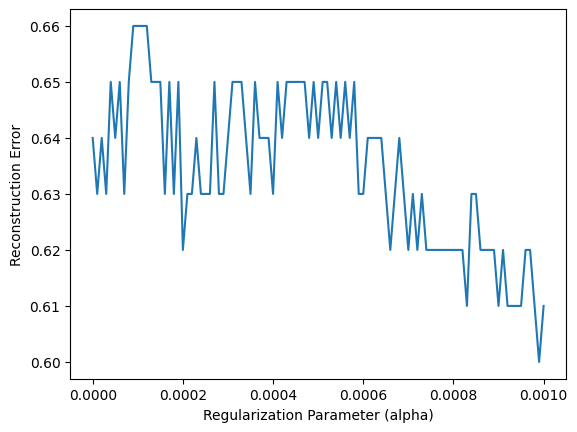

In [64]:
plt.plot(regularization_params, np.mean(scores, axis = 1))
plt.xlabel('Regularization Parameter (alpha)')
plt.ylabel('Reconstruction Error')

In [67]:
regularization_params[np.argmax(np.mean(scores, axis=1))]

np.float64(9e-05)

In [77]:
# Fit logistic regression model
alpha = 9e-05
model = LogisticRegression(C = 1/(alpha + 1e-10), penalty = "l1", solver='liblinear', max_iter=1000, random_state = 342)
model.fit(X, y)
#train_accuracy = model.score(X_train, y_train)
#print(f"Logistic Regression Train Accuracy: {train_accuracy:.4f}")
#accuracy = model.score(X, y)
#print(f"Logistic Regression Test Accuracy: {accuracy:.4f}")

coefficients = model.coef_[0]
context_coefficients = coefficients[:-32].reshape(32, 32)
parametric_coefficients = coefficients[-32:]

In [53]:
model.predict(X_test)

array([0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0])

In [54]:
y_test

83    0
53    0
70    1
45    1
44    1
39    0
22    0
80    1
10    1
0     1
18    0
30    1
73    1
33    0
90    1
4     1
76    0
77    1
12    1
31    0
Name: validation_status, dtype: int64

In [39]:
pond_df

,author,title,name,location,ecosystem,measurement,value
0,kuczynska-kippen; n.; basinska; a. m.; swidnic...,specificity of zooplankton distribution in met...,meteor1,western poland,meteorite crater ponds,depth,1.0
1,kuczynska-kippen; n.; basinska; a. m.; swidnic...,specificity of zooplankton distribution in met...,meteor2,western poland,meteorite crater ponds,depth,1.0
2,kuczynska-kippen; n.; basinska; a. m.; swidnic...,specificity of zooplankton distribution in met...,meteor3,western poland,meteorite crater ponds,depth,0.3
3,kuczynska-kippen; n.; basinska; a. m.; swidnic...,specificity of zooplankton distribution in met...,meteor4,western poland,meteorite crater ponds,depth,0.7
4,hanrahan,multivariate chemometrical classification and ...,lake tuendae,mojave desert; california; united states,aquatic environment,depth,1.7
...,...,...,...,...,...,...,...
3405,eskinazi-sant'anna; eneida maria; pace; michae...,the potential of the zooplankton resting-stage...,coutos,brazil,temporary lake/seasonal pond,chl,4.5
3406,eskinazi-sant'anna; eneida maria; pace; michae...,the potential of the zooplankton resting-stage...,seca,brazil,temporary lake,chl,8.2
3407,sepulveda-jauregui; armando; martinez-cruz; ka...,assessment of methane and carbon dioxide emiss...,grosse fuchskuhle,mecklenburg-brandenburg lake district,small acidic bog lake,chl,8.0
3408,sepulveda-jauregui; armando; martinez-cruz; ka...,assessment of methane and carbon dioxide emiss...,grosse fuchskuhle ne,mecklenburg-brandenburg lake district,small acidic bog lake,chl,32.3


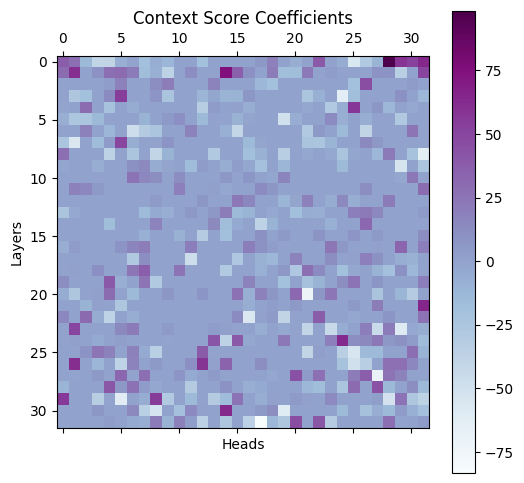

In [78]:
fig,ax = plt.subplots(figsize=(6,6), dpi = 100)
pos = ax.matshow(context_coefficients, cmap='BuPu')
ax.set_ylabel('Layers')
ax.set_xlabel('Heads')
ax.set_title(f'Context Score Coefficients')
fig.colorbar(pos, ax=ax)

Text(0.5, 0, 'Layers')

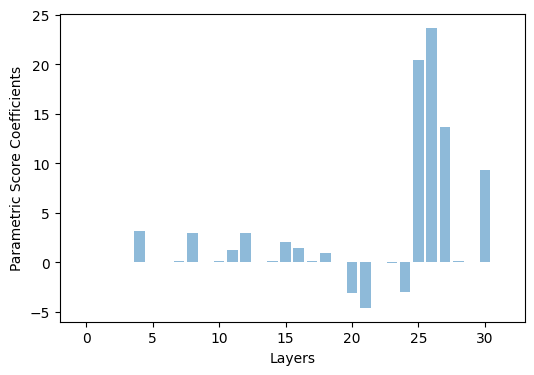

In [79]:
fig,ax = plt.subplots(figsize=(6,4), dpi = 100)
ax.bar(
    range(len(parametric_coefficients)), parametric_coefficients, alpha = 0.5
)
ax.set_ylabel('Parametric Score Coefficients')
ax.set_xlabel('Layers')

### Matching to dataset

In [15]:
'''
def match_datapoints(ground_truth, extracted):
    matching = {}
    for i, row in ground_truth.iterrows():
        title = row['title']
        name = row['name']
        measurement = row['measurement']
        val = row['value']

        if title in extracted['title'].values:
            extracted_title_entries = extracted.loc[extracted['title'] == title]
            
            # find any close matches in name
            extracted_title_names = extracted_title_entries['name'].values
            indx = []
            for j, name in enumerate(extracted_title_names):
                ratio = fuzz.ratio(row['name'], name)
                if ratio > 0:  # threshold for a close match
                    indx.append(extracted_title_entries.index[j])

            if len(indx) > 0:
                extracted_title_entries = extracted_title_entries.loc[indx]
                extracted_title_values = extracted_title_entries.loc[extracted_title_entries.measurement == measurement]['value']

                # check if any value is close enough
                close_enough = np.isclose(extracted_title_values, val, atol=1e-3)
                if np.any(close_enough):
                    if np.sum(close_enough) > 1:
                        print(f"Warning: multiple close matches found for row {i} in ground truth.")
                    closest = np.where(close_enough)[0][0]
                    extracted_row = extracted_title_entries.iloc[closest]
                    matching[i] = extracted_row.name

    return matching
'''

def match_datapoints(ground_truth, extracted):
    edges = []
    edge_weights = []
    for i, row_gt in ground_truth.iterrows():
        for j, row_ex in extracted.iterrows():
            if (
                row_gt['title'] == row_ex['title'] and 
                row_gt['measurement'] == row_ex['measurement'] and 
                np.isclose(row_gt['value'], row_ex['value'], atol=1e-3)
            ):
                name_similarity = fuzz.ratio(row_gt['name'], row_ex['name']) / 100.0
                location_similarity = fuzz.ratio(row_gt['location'], row_ex['location']) / 100.0
                ecosystem_similarity = fuzz.ratio(row_gt['ecosystem'], row_ex['ecosystem']) / 100.0
                weight = (name_similarity + location_similarity + ecosystem_similarity) / 3.0
                edges.append((i, j))
                edge_weights.append(weight)

    print(f"Total edges found: {len(edges)}")
    # Create a bipartite graph and find maximum weight matching
    G = nx.Graph()
    G.add_edges_from([(f"gt_{i}", f"ex_{j}", {'weight': w}) for (i, j), w in zip(edges, edge_weights)])
    matching = nx.algorithms.matching.max_weight_matching(G)
    index_matching = []
    for i, j in matching:
        if i.startswith("gt_"):
            index_matching.append((int(i[3:]), int(j[3:])))
        else:
            index_matching.append((int(j[3:]), int(i[3:])))
    
    return index_matching


def estimate_precision_recall(ground_truth, extracted, measurement_cols):
    total_ground_truth = ground_truth.shape[0]
    total_extracted = extracted.shape[0]

    matched_indices = set()
    for col in measurement_cols:
        matches = match_datapoints(ground_truth, extracted, col)
        matched_indices.update(matches.values())

    true_positives = len(matched_indices)
    precision = true_positives / total_extracted if total_extracted > 0 else 0
    recall = true_positives / total_ground_truth if total_ground_truth > 0 else 0

    return precision, recall

In [16]:
matching = match_datapoints(pond_df, result_df)

Total edges found: 30


In [17]:
len(matching)

20

In [18]:
matching

[(140, 55),
 (22, 95),
 (156, 64),
 (139, 54),
 (62, 61),
 (30, 126),
 (102, 52),
 (120, 67),
 (21, 8),
 (18, 56),
 (63, 65),
 (119, 51),
 (84, 89),
 (0, 6),
 (19, 50),
 (64, 59),
 (20, 57),
 (33, 131),
 (104, 58),
 (157, 62)]

In [19]:
match = 12
print("Ground Truth:")
print(pond_df.iloc[matching[match][0], :])
print("\nExtracted:")
print(result_df.iloc[matching[match][1], :11])

Ground Truth:
author                                                        ng
title          bacterioplankton in the littoral and pelagic z...
name                                                    ipe (ip)
location                rio grande do sul state; southern brazil
ecosystem                               subtropical shallow lake
measurement                                                   ph
value                                                        7.5
Name: 84, dtype: object

Extracted:
title          bacterioplankton in the littoral and pelagic z...
author                                                        ng
year                                                        2010
date                                                         NaN
context        <table>\n  <tr>\n    <th>Lake</th>\n    <th>SP...
ecosystem                                                   lake
location                                29°55'17''S, 50°11'55''W
chunk_id                                

In [21]:
20 * 12

240